In [117]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from collections import Counter
import os
import glob

In [118]:
#extract data from txt files
def extract_data(file):
    with open(file, 'r', encoding='utf-8') as f:
        return f.read().splitlines()
train_text = extract_data('data/train_text.txt')
val_text = extract_data('data/val_text.txt')
test_text = extract_data('data/test_text.txt')

train_labels = extract_data('data/train_labels.txt')
val_labels = extract_data('data/val_labels.txt')
test_labels = extract_data('data/test_labels.txt')

print("Data Sample:")
print("Text:", train_text[0])
    

Data Sample:
Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 


In [119]:
#loads adjective and frequent word lexicons
lex_adj = pd.read_csv("lexicons/socialsent_hist_adj/adjectives/2000.tsv", sep="\t", names = ["word", "score"])
lex_freq = pd.read_csv("lexicons/socialsent_hist_freq/frequent_words/2000.tsv", sep="\t", names = ["word", "score"])

print("\nAdjective Lexicon Sample:")
print(lex_adj.head())


Adjective Lexicon Sample:
           word  score
vile      -3.18   0.61
tragic    -3.15   0.66
ugly      -3.10   0.49
traumatic -3.08   0.68
stinging  -3.05   0.56


In [120]:
#Loads subreddit lexicon, ensuring no duplicates based on first character of filename
subr= glob.glob("lexicons/socialsent_subreddits/subreddits/*.tsv")
print(subr)
subr_lex = []
seen_chars = set()
for file in subr:
    f_name = os.path.basename(file)
    f_char = f_name[0]
    if f_char.isdigit() and f_char not in seen_chars:
        df = pd.read_csv(file, sep="\t", names = ["word", "score"])
        subr_lex.append(df)
        seen_chars.add(f_char)
    elif f_char.isalpha() and f_char not in seen_chars:
        df = pd.read_csv(file, sep="\t", names = ["word", "score"])
        subr_lex.append(df)
        seen_chars.add(f_char)
subr_lex = pd.concat(subr_lex, ignore_index=True)
print(subr_lex)

['lexicons/socialsent_subreddits/subreddits\\2007scape.tsv', 'lexicons/socialsent_subreddits/subreddits\\3DS.tsv', 'lexicons/socialsent_subreddits/subreddits\\4chan.tsv', 'lexicons/socialsent_subreddits/subreddits\\ACTrade.tsv', 'lexicons/socialsent_subreddits/subreddits\\AdviceAnimals.tsv', 'lexicons/socialsent_subreddits/subreddits\\amiugly.tsv', 'lexicons/socialsent_subreddits/subreddits\\Anarcho_Capitalism.tsv', 'lexicons/socialsent_subreddits/subreddits\\Android.tsv', 'lexicons/socialsent_subreddits/subreddits\\anime.tsv', 'lexicons/socialsent_subreddits/subreddits\\apple.tsv', 'lexicons/socialsent_subreddits/subreddits\\archeage.tsv', 'lexicons/socialsent_subreddits/subreddits\\AskMen.tsv', 'lexicons/socialsent_subreddits/subreddits\\askscience.tsv', 'lexicons/socialsent_subreddits/subreddits\\AskWomen.tsv', 'lexicons/socialsent_subreddits/subreddits\\asoiaf.tsv', 'lexicons/socialsent_subreddits/subreddits\\atheism.tsv', 'lexicons/socialsent_subreddits/subreddits\\australia.tsv',

In [121]:
#create dictionaries for lexicons
adj_dict = dict(zip(lex_adj['word'], lex_adj['score']))
freq_dict = dict(zip(lex_freq['word'], lex_freq['score']))
subr_dict = dict(zip(subr_lex['word'], subr_lex['score']))

In [122]:
#tokenization function
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()


In [123]:
#feature extraction function
def extract_features(text):
    words = tokenize(text)
    lex_adj_score =[]
    lex_freq_score = []
    lex_subr_score = []
    for w in words:
        if w in adj_dict:
            lex_adj_score.append(adj_dict[w])
        if w in freq_dict:
            lex_freq_score.append(freq_dict[w])
        if w in subr_dict:
            lex_subr_score.append(subr_dict[w]) 
    #mean sentiment scores for each lexicon
    f1 = np.mean(lex_adj_score) if lex_adj_score else 0
    f2 = np.mean(lex_freq_score) if lex_freq_score else 0
    f3 = np.mean(lex_subr_score) if lex_subr_score else 0
    
    #lexicon score counts
    f4 = len([x for x in lex_adj_score if x > 0])
    f5 = len([x for x in lex_adj_score if x < 0])

    f6 = len([x for x in lex_freq_score if x > 0])
    f7 = len([x for x in lex_freq_score if x < 0])

    f8 = len([x for x in lex_subr_score if x > 0])
    f9 = len([x for x in lex_subr_score if x < 0])

    #text statistics
    word_count = len(words)
    longest_word = max([len(w) for w in words]) if words else 1
    long_words = len([w for w in words if len(w) >= 5])
    f10 = np.log(word_count + 1)
    f11 = np.log(longest_word + 1)
    f12 = np.log(long_words + 1)
    return [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12]






In [124]:
#extract features for all datasets
xtrain = np.array([extract_features(text) for text in train_text])
xval = np.array([extract_features(text) for text in val_text])
xtest = np.array([extract_features(text) for text in test_text])

ytrain = np.array(train_labels).astype(int)
yval = np.array(val_labels).astype(int)
ytest = np.array(test_labels).astype(int)

In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

In [126]:
#dataset class
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [127]:
#data loaders
train_loader = DataLoader(FeatureDataset(xtrain, ytrain), batch_size=32, shuffle=True)
val_loader = DataLoader(FeatureDataset(xval, yval), batch_size=32)
test_loader = DataLoader(FeatureDataset(xtest, ytest), batch_size=32)

In [128]:
#model definition
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes = 3):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

In [129]:
#training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LogisticRegression(input_dim=xtrain.shape[1], num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [130]:
#training function
def train_model(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(features)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


In [131]:
#evaluation function
def evaluate_model(model, loader):
    model.eval()
    preds_list, labels_list = [], []

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            preds = torch.argmax(logits, dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list, average='weighted')

    
    return acc, f1

In [132]:
#training loop
epochs = 10

for e in range(epochs):
    loss = train_model(model, train_loader, optimizer, criterion)
    val_acc, val_f1 = evaluate_model(model, val_loader)

    print(f"Epoch {e+1}: Loss: {loss:.4f}, Validation Accuracy: {val_acc:.4f}, Validation F1-Score: {val_f1:.4f}")

Epoch 1: Loss: 1.0368, Validation Accuracy: 0.4405, Validation F1-Score: 0.2979
Epoch 2: Loss: 1.0105, Validation Accuracy: 0.4480, Validation F1-Score: 0.3365
Epoch 3: Loss: 1.0103, Validation Accuracy: 0.4485, Validation F1-Score: 0.3431
Epoch 4: Loss: 1.0103, Validation Accuracy: 0.4430, Validation F1-Score: 0.3188
Epoch 5: Loss: 1.0104, Validation Accuracy: 0.4520, Validation F1-Score: 0.3327
Epoch 6: Loss: 1.0104, Validation Accuracy: 0.4500, Validation F1-Score: 0.3420
Epoch 7: Loss: 1.0103, Validation Accuracy: 0.4450, Validation F1-Score: 0.3379
Epoch 8: Loss: 1.0103, Validation Accuracy: 0.4400, Validation F1-Score: 0.3088
Epoch 9: Loss: 1.0102, Validation Accuracy: 0.4460, Validation F1-Score: 0.3514
Epoch 10: Loss: 1.0103, Validation Accuracy: 0.4435, Validation F1-Score: 0.3198


In [133]:
#final evaluation on test set
test_acc, test_f1 = evaluate_model(model, test_loader)
print("Test Results:")
print(f"Test Accuracy: {test_acc:.4f} \nTest F1-Score: {test_f1:.4f}")

Test Results:
Test Accuracy: 0.4718 
Test F1-Score: 0.3378


In [134]:
#confusion matrix visualization
def eval_model(model, loader):
    model.eval()
    preds_list, labels_list = [], []

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            preds = torch.argmax(logits, dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
    return preds_list, labels_list

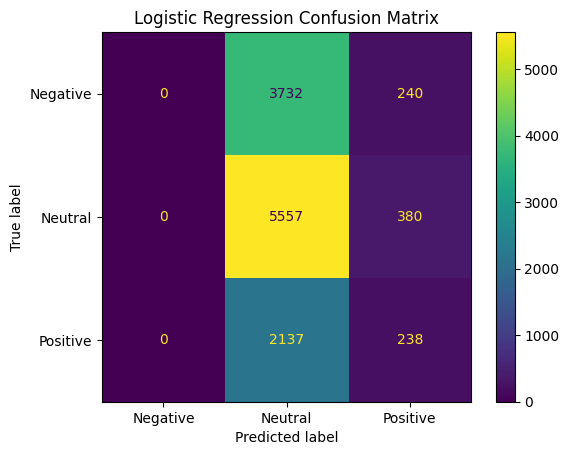

In [136]:
#confusion matrix visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds_list, labels_list = eval_model(model, test_loader)
cm = confusion_matrix(labels_list, preds_list)
disp = ConfusionMatrixDisplay(cm, display_labels = ["Negative", "Neutral", "Positive"])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [137]:
class NeuralNetModel(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [138]:
nn_model = NeuralNetModel(input_dim=xtrain.shape[1]).to(device)
nn_optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)
nn_criterion = nn.CrossEntropyLoss()


In [139]:
epochs = 10
for e in range(epochs):
    loss = train_model(nn_model, train_loader, nn_optimizer, nn_criterion)
    val_acc, val_f1 = evaluate_model(nn_model, val_loader)

    print(f"Epoch {e+1}: Loss: {loss:.4f}, Validation Accuracy: {val_acc:.4f}, Validation F1-Score: {val_f1:.4f}")

Epoch 1: Loss: 1.0119, Validation Accuracy: 0.4345, Validation F1-Score: 0.2632
Epoch 2: Loss: 1.0100, Validation Accuracy: 0.4335, Validation F1-Score: 0.2682
Epoch 3: Loss: 1.0096, Validation Accuracy: 0.4560, Validation F1-Score: 0.3830
Epoch 4: Loss: 1.0092, Validation Accuracy: 0.4485, Validation F1-Score: 0.4005
Epoch 5: Loss: 1.0089, Validation Accuracy: 0.4350, Validation F1-Score: 0.2835
Epoch 6: Loss: 1.0086, Validation Accuracy: 0.4360, Validation F1-Score: 0.2856
Epoch 7: Loss: 1.0086, Validation Accuracy: 0.4450, Validation F1-Score: 0.3554
Epoch 8: Loss: 1.0083, Validation Accuracy: 0.4365, Validation F1-Score: 0.2994
Epoch 9: Loss: 1.0082, Validation Accuracy: 0.4355, Validation F1-Score: 0.2856
Epoch 10: Loss: 1.0082, Validation Accuracy: 0.4435, Validation F1-Score: 0.3492


In [140]:
#final evaluation on test set
test_acc, test_f1 = evaluate_model(nn_model, test_loader)
print("Test Results:")
print(f"Test Accuracy: {test_acc:.4f} \nTest F1-Score: {test_f1:.4f}")

Test Results:
Test Accuracy: 0.4532 
Test F1-Score: 0.3371


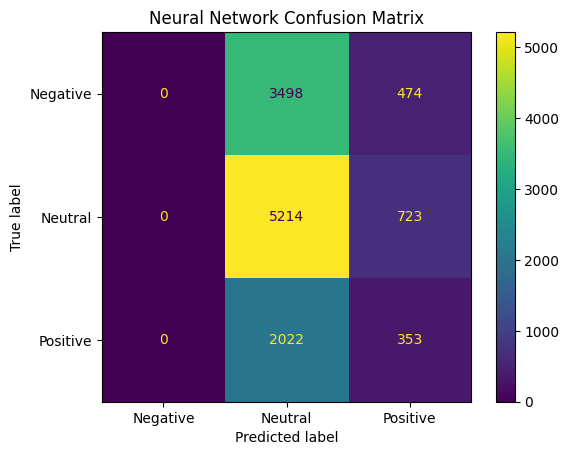

In [141]:


preds_list, labels_list = eval_model(nn_model, test_loader)
cm = confusion_matrix(labels_list, preds_list)
disp = ConfusionMatrixDisplay(cm, display_labels = ["Negative", "Neutral", "Positive"])
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [142]:
print("Model Comparison:\n")
print("Logistic Regression")
lr_test_acc, lr_test_f1 = evaluate_model(model, test_loader)

print("Test Accuracy:", lr_test_acc, "\nTest F1:", lr_test_f1,"\n")


print("Neural Network")
nn_test_acc, nn_test_f1 = evaluate_model(nn_model, test_loader)

print("Test Accuracy:", nn_test_acc, "\nTest F1:", nn_test_f1)

Model Comparison:

Logistic Regression
Test Accuracy: 0.471751872354282 
Test F1: 0.3378321127780738 

Neural Network
Test Accuracy: 0.4531911429501791 
Test F1: 0.33709655251657356


In [ ]:
torch.save(model.state_dict(), "model.pt")
torch.save(nn_model.state_dict(), "nn_model.pt")